In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
dir = './data'
train_sequences = pd.read_pickle(f"{dir}/train_sequences.pkl")
test_sequences = pd.read_pickle(f"{dir}/test_sequences.pkl")

In [11]:
train_sequences.shape, test_sequences.shape

((285980, 34), (291575, 34))

In [4]:
train_sequences.head(1)

,date,smart_9_raw,smart_197_raw,smart_241_raw,smart_242_raw,smart_7_raw,smart_193_raw,smart_1_raw,smart_240_raw,smart_198_raw,...,smart_196_raw,smart_183_raw,smart_199_raw,smart_200_raw,smart_225_raw,serial_number,model,capacity_bytes,failure,label
0,2016-10-13,0.722535,0.0,0.0,0.0,0.0,0.000369,0.0,0.0,0.0,...,0.714656,0.0,0.0,0.0,0.0,MJ0351YNG9ZJAA,Hitachi HDS5C3030ALA630,3.000593e+12,0.0,1


### Splitting and Reshaping Train/Test

In [12]:
X_train = train_sequences.drop(columns=['label', 'serial_number', 'date', 'model', 'capacity_bytes', 'failure'])
y_train = train_sequences['label']

In [13]:
X_train.shape, y_train.shape

((285980, 28), (285980,))

In [14]:
X_test = test_sequences.drop(columns=['label', 'serial_number', 'date', 'model', 'capacity_bytes', 'failure'])
y_test = test_sequences['label']

In [8]:
X_test.shape, y_test.shape

((291575, 28), (291575,))

In [9]:
X_train.columns

Index(['smart_9_raw', 'smart_197_raw', 'smart_241_raw', 'smart_242_raw',
       'smart_7_raw', 'smart_193_raw', 'smart_1_raw', 'smart_240_raw',
       'smart_198_raw', 'smart_194_raw', 'smart_4_raw', 'smart_12_raw',
       'smart_187_raw', 'smart_192_raw', 'smart_190_raw', 'smart_5_raw',
       'smart_3_raw', 'smart_195_raw', 'smart_189_raw', 'smart_191_raw',
       'smart_2_raw', 'smart_188_raw', 'smart_8_raw', 'smart_196_raw',
       'smart_183_raw', 'smart_199_raw', 'smart_200_raw', 'smart_225_raw'],
      dtype='str')

In [15]:
sequence_length = 5
num_features = X_train.shape[1]

In [16]:
def create_sequences(df, feature_cols, sequence_length):
    X = []
    y = []

    for drive in df['serial_number'].unique():
        df_drive = df[df['serial_number'] == drive].sort_values('date')

        data = df_drive[feature_cols].values
        labels = df_drive['label'].values

        for i in range(len(df_drive) - sequence_length):
            X.append(data[i:i+sequence_length])
            y.append(labels[i+sequence_length-1])

    return np.array(X), np.array(y)

In [17]:
feature_cols = X_train.columns.tolist()

X_train, y_train = create_sequences(train_sequences, feature_cols, 5)
X_test, y_test = create_sequences(test_sequences, feature_cols, 5)

In [13]:
X_train.shape, y_train.shape

((281875, 5, 28), (281875,))

In [14]:
X_test.shape, y_test.shape

((287225, 5, 28), (287225,))

In [15]:
print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([280618,   1257]))


### Modeling

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.regularizers import l2

In [19]:
kernel_size = 2
filters = 64
lstm_units = 64
dropout_rate = 0.3
recurrent_dropout_rate = 0.2
l2_lambda = 0.001

In [20]:
model = Sequential()

model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same',
                 input_shape=(sequence_length, num_features)))

model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', padding='same'))

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(lstm_units, return_sequences=True,
                dropout=dropout_rate, recurrent_dropout=recurrent_dropout_rate))

model.add(LSTM(lstm_units, return_sequences=False,
                dropout=dropout_rate, recurrent_dropout=recurrent_dropout_rate))

model.add(Dense(64, activation='tanh', kernel_regularizer=l2(l2_lambda)))

model.add(Dropout(dropout_rate))

model.add(Dense(1, activation='sigmoid'))

C:\Users\affi-\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │         3,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 64)          │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 2, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,177 (321.00 KB)

 Trainable params: 82,177 (321.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [34]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [40]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Fix: Build the model first if not already built
model.build(input_shape=(None, 5, num_features))

# Method: Use keras.utils.plot_model with graphviz fallback
try:
    from tensorflow.keras.utils import plot_model
    plot_model(
        model,
        to_file='cnn_lstm_architecture.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB'
    )
    print("Architecture saved as 'cnn_lstm_architecture.png'")
except:
    print("plot_model failed, trying alternative...")

# Alternative: Print architecture table
def print_architecture_table(model):
    print("\n" + "="*70)
    print(f"{'Layer (type)':<30} {'Output Shape':<25} {'Param #':<10}")
    print("="*70)
    for layer in model.layers:
        try:
            shape = layer.output_shape
        except:
            shape = "Unknown"
        print(f"{layer.name:<30} {str(shape):<25} {layer.count_params():<10}")
    print("="*70)

print_architecture_table(model)

# Save to file
with open('model_architecture.txt', 'w') as f:
    f.write("CNN-LSTM Model Architecture\n")
    f.write("="*70 + "\n")
    f.write(f"{'Layer (type)':<30} {'Output Shape':<25} {'Param #':<10}\n")
    f.write("="*70 + "\n")
    for layer in model.layers:
        try:
            shape = layer.output_shape
        except:
            shape = "Unknown"
        f.write(f"{layer.name:<30} {str(shape):<25} {layer.count_params():<10}\n")
    f.write("="*70 + "\n")
    f.write(f"\nTotal params: {model.count_params():,}\n")

print("Architecture saved to 'model_architecture.txt'")

You must install pydot (`pip install pydot`) for `plot_model` to work.
Architecture saved as 'cnn_lstm_architecture.png'

Layer (type)                   Output Shape              Param #   
conv1d                         Unknown                   3648      
conv1d_1                       Unknown                   8256      
max_pooling1d                  Unknown                   0         
lstm                           Unknown                   33024     
lstm_1                         Unknown                   33024     
dense                          Unknown                   4160      
dropout                        Unknown                   0         
dense_1                        Unknown                   65        
Architecture saved to 'model_architecture.txt'


In [21]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights))

print(class_weights)

{np.int64(0): np.float64(0.5022396995203444), np.int64(1): np.float64(112.12211614956244)}


In [25]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    class_weight = {0: 1, 1: 50}
)

Epoch 1/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 39s 9ms/step - accuracy: 0.9681 - loss: 0.5215 - val_accuracy: 0.9669 - val_loss: 0.1700
Epoch 2/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - accuracy: 0.9693 - loss: 0.5218 - val_accuracy: 0.9643 - val_loss: 0.1765
Epoch 3/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - accuracy: 0.9675 - loss: 0.5177 - val_accuracy: 0.9710 - val_loss: 0.1432
Epoch 4/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.9703 - loss: 0.5233 - val_accuracy: 0.9698 - val_loss: 0.2170
Epoch 5/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 48s 11ms/step - accuracy: 0.9721 - loss: 0.5213 - val_accuracy: 0.9719 - val_loss: 0.1357
Epoch 6/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - accuracy: 0.9690 - loss: 0.5208 - val_accuracy: 0.9612 - val_loss: 0.2495
Epoch 7/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 49s 11ms/step - accuracy: 0.9703 - loss: 0.5211 - val_accuracy: 0.9697 - val_loss: 0.2294
Epoch 8/10
4405/4405 ━━━━━━━━━━━━━━━━━━━━ 46s 10ms/step - accuracy: 0.9692 - 

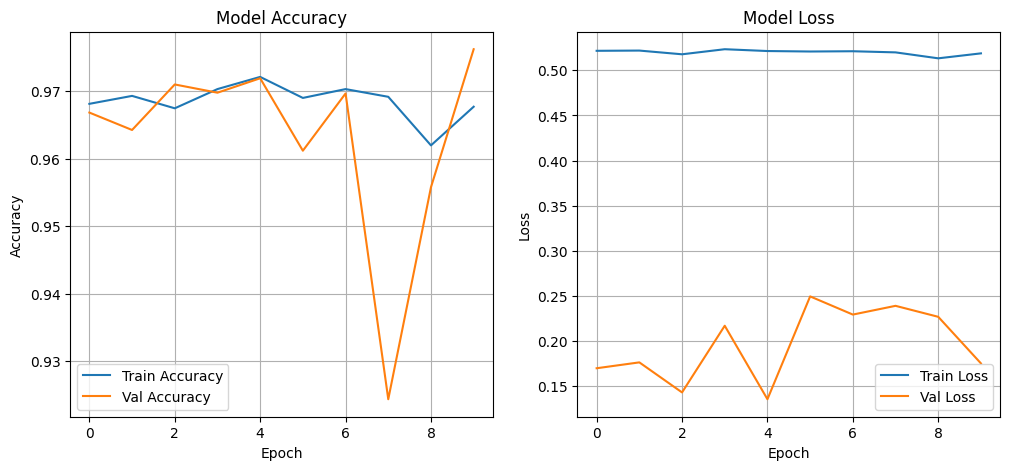

In [29]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)


8976/8976 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step
[[280162   5633]
 [  1188    242]]


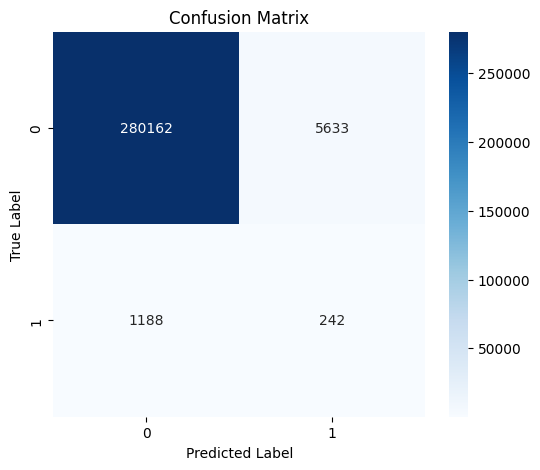

In [30]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

NameError: name 'y_pred' is not defined

8976/8976 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


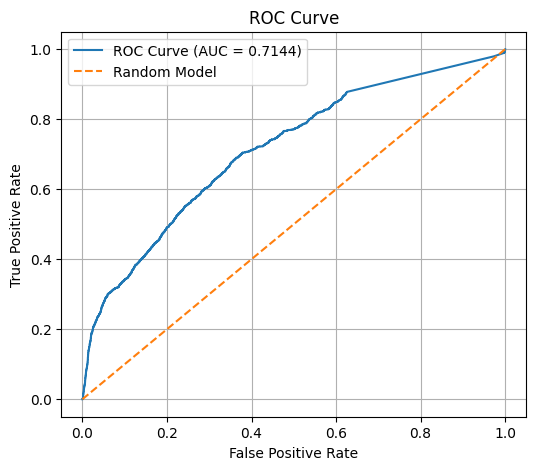

In [31]:
from sklearn.metrics import roc_curve, auc

y_proba = model.predict(X_test).ravel()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Model')

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()
plt.grid()

plt.show()